In [1]:
# ============================================================
# STEP 1: ENVIRONMENT SETUP & IMPORTS
# ============================================================

# ── Install dependencies ─────────────────────────────────────
!pip install -q imbalanced-learn xgboost

# ── GPU Check ────────────────────────────────────────────────
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

# GPU memory growth enable karo
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# ── Standard Library ─────────────────────────────────────────
import os, json, glob, warnings
warnings.filterwarnings("ignore")

# ── Data Handling ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Signal Processing ─────────────────────────────────────────
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq

# ── ML / Sklearn ──────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

# ── XGBoost ───────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Deep Learning ─────────────────────────────────────────────
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
                                     Activation, MaxPooling1D, Dropout,
                                     Bidirectional, LSTM, Dense,
                                     GlobalAveragePooling1D, Multiply,
                                     Permute, Flatten, Lambda, Reshape)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Global Config ─────────────────────────────────────────────
SAMPLE_RATE        = 100
WINDOW_SIZE        = 300
STEP_SIZE          = 150
N_AXES             = 6
N_FEATURES_PER_AX  = 14
TOTAL_FEATURES     = N_AXES * N_FEATURES_PER_AX
TOP_VOICE_FEATS    = 12

print("✅ Setup complete")
print(f"   TensorFlow : {tf.__version__}")
print(f"   GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"   Numpy      : {np.__version__}")
print(f"   Pandas     : {pd.__version__}")

2026-05-28 00:23:13.251862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779927793.435050      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779927793.488500      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779927793.934079      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779927793.934117      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779927793.934120      24 computation_placer.cc:177] computation placer alr

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ Setup complete
   TensorFlow : 2.19.0
   GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
   Numpy      : 2.4.6
   Pandas     : 2.3.3


In [2]:
import os

# Check what's inside the parkinsons folder
uci_folder = "/kaggle/input/datasets/shaanayamughal/cloud-computing-article/parkinsons"
print(os.listdir(uci_folder))

['parkinsons.names', 'telemonitoring', 'parkinsons.data']


In [3]:
# ============================================================
# STEP 2: DATA LOADING (KAGGLE PATHS)
# ============================================================

import os
import glob
import json
import numpy as np
import pandas as pd

# ── Kaggle Input Paths ────────────────────────────────────────
PADS_ROOT  = "/kaggle/input/datasets/shaanayamughal/cloud-computing-article/pads-parkinsons-disease-smartwatch-dataset-1.0.0"
UCI_PATH   = "/kaggle/input/datasets/shaanayamughal/cloud-computing-article/parkinsons/parkinsons.data"

# ── Deep Search Helper ────────────────────────────────────────
def find_dir_deep(root, target_name):
    for r, dirs, files in os.walk(root):
        if target_name in dirs:
            return os.path.abspath(os.path.join(r, target_name))
    return None

PATIENTS_DIR   = find_dir_deep(PADS_ROOT, "patients")
MOVEMENT_DIR   = find_dir_deep(PADS_ROOT, "movement")
TIMESERIES_DIR = os.path.join(MOVEMENT_DIR, "timeseries") if MOVEMENT_DIR else None

print(f"Patients Dir  : {PATIENTS_DIR}")
print(f"Timeseries Dir: {TIMESERIES_DIR}")
print(f"UCI Path      : {UCI_PATH}")

# ── Label Extractor ───────────────────────────────────────────
def _extract_label_from_patient(p: dict) -> int:
    cond = str(p.get("condition", p.get("Subject type", ""))).strip().lower()
    if any(x in cond for x in ["parkinson", "pd", "patient"]):
        return 1
    if any(x in cond for x in ["healthy", "control", "hc", "normal"]):
        return 0
    return -1

# ── Load Patient Metadata ─────────────────────────────────────
def load_patient_metadata(patients_dir):
    if not patients_dir or not os.path.exists(patients_dir):
        print("❌ Patients directory not found!")
        return pd.DataFrame()
    records = []
    for fpath in sorted(glob.glob(os.path.join(patients_dir, "*.json"))):
        with open(fpath) as f:
            p = json.load(f)
        label = _extract_label_from_patient(p)
        pid = str(p.get("id") or os.path.basename(fpath).replace(".json", "")).zfill(3)
        records.append({
            "participant_id": pid,
            "label": label,
            "age": p.get("age", p.get("Age")),
            "diagnosis": p.get("condition", p.get("diagnosis", "unknown"))
        })
    df = pd.DataFrame(records)
    df = df[df["label"] != -1].reset_index(drop=True)
    print(f"   Loaded metadata: {len(df)} patients")
    return df

# ── Load PADS Signals ─────────────────────────────────────────
def load_all_pads_signals(timeseries_dir, metadata_df):
    if metadata_df.empty or not timeseries_dir or not os.path.exists(timeseries_dir):
        print("❌ Timeseries directory not found!")
        return {}
    valid_pids = set(metadata_df["participant_id"].tolist())
    pid_signals = {}
    for fpath in sorted(glob.glob(os.path.join(timeseries_dir, "*.txt"))):
        pid = os.path.basename(fpath).split("_")[0].zfill(3)
        if pid in valid_pids:
            try:
                data = pd.read_csv(fpath, header=None, comment="#",
                                   sep=r"[\s,\t]+", engine="python").iloc[:, :6]
                arr = data.values.astype(np.float32)
                if len(arr) >= 300:
                    pid_signals.setdefault(pid, []).append(arr)
            except:
                continue
    return {pid: np.concatenate(arrays, axis=0) for pid, arrays in pid_signals.items()}

# ── Run Loading ───────────────────────────────────────────────
print("\nLoading PADS data...")
pads_meta   = load_patient_metadata(PATIENTS_DIR)
pads_signals = load_all_pads_signals(TIMESERIES_DIR, pads_meta)
if not pads_meta.empty:
    pid_label = dict(zip(pads_meta["participant_id"], pads_meta["label"]))
print(f"   Signals loaded: {len(pads_signals)} participants")

print("\nLoading UCI Voice data...")
voice_df = pd.read_csv(UCI_PATH)
VOICE_FEATURE_COLS = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)',
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ',
    'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)',
    'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA',
    'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE'
]
X_voice_raw = voice_df[VOICE_FEATURE_COLS].values.astype(np.float32)
y_voice     = voice_df["status"].values.astype(np.int32)

print("✅ Loading complete.")
print(f"   Voice samples : {len(y_voice)}")

Patients Dir  : /kaggle/input/datasets/shaanayamughal/cloud-computing-article/pads-parkinsons-disease-smartwatch-dataset-1.0.0/pads-parkinsons-disease-smartwatch-dataset-1.0.0/patients
Timeseries Dir: /kaggle/input/datasets/shaanayamughal/cloud-computing-article/pads-parkinsons-disease-smartwatch-dataset-1.0.0/pads-parkinsons-disease-smartwatch-dataset-1.0.0/movement/timeseries
UCI Path      : /kaggle/input/datasets/shaanayamughal/cloud-computing-article/parkinsons/parkinsons.data

Loading PADS data...
   Loaded metadata: 370 patients
   Signals loaded: 370 participants

Loading UCI Voice data...
✅ Loading complete.
   Voice samples : 195


Sample JSON: /kaggle/input/datasets/shaanayamughal/cloud-computing-article/pads-parkinsons-disease-smartwatch-dataset-1.0.0/pads-parkinsons-disease-smartwatch-dataset-1.0.0/patients/patient_467.json
{
  "resource_type": "patient",
  "id": "467",
  "study_id": "PADS",
  "condition": "Parkinson's",
  "disease_comment": "Essential Tremor, starting IPS tremordominant type",
  "age_at_diagnosis": 55,
  "age": 57,
  "height": 190,
  "weight": 100,
  "gender": "male",
  "handedness": "right",
  "appearance_in_kinship": false,
  "appearance_in_first_grade_kinship": null,
  "effect_of_alcohol_on_tremor": "Improvement"
}

PADS Metadata (first 5 rows):


,participant_id,label,age,diagnosis
0,001,0,56,Healthy
1,003,0,45,Healthy
2,004,1,67,Parkinson's
3,005,1,75,Parkinson's
4,006,1,72,Parkinson's



Unique values in PADS 'diagnosis' column:


array(['Healthy', "Parkinson's", 'Atypical Parkinsonism'], dtype=object)


Columns in pads_meta:


['participant_id', 'label', 'age', 'diagnosis']


Summary statistics for 'age':


count    370.000000
mean      64.870270
std       10.269244
min       40.000000
25%       56.250000
50%       66.000000
75%       73.000000
max       90.000000
Name: age, dtype: float64

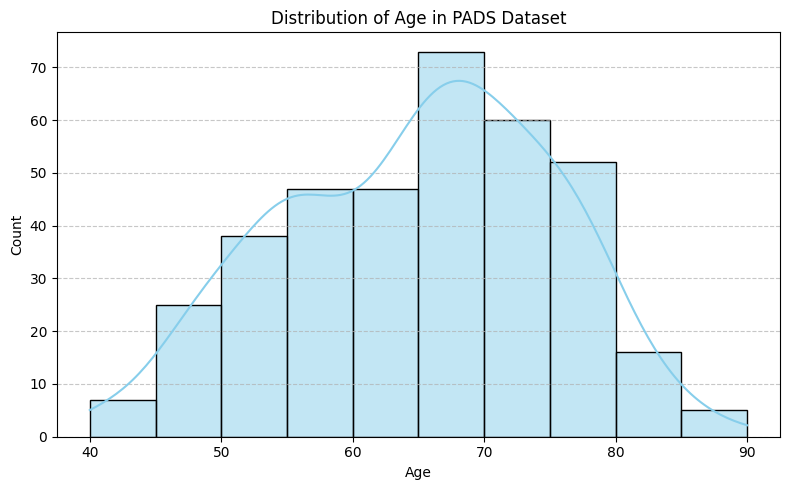

In [4]:
# ============================================================
# STEP 3: PADS DATA EXPLORATION
# ============================================================
import glob, json
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sample JSON Inspection ────────────────────────────────────
sample_json_path = glob.glob(os.path.join(PATIENTS_DIR, "*.json"))[0]
print(f"Sample JSON: {sample_json_path}")
with open(sample_json_path) as f:
    sample_metadata = json.load(f)
print(json.dumps(sample_metadata, indent=2))

# ── PADS Metadata ─────────────────────────────────────────────
print("\nPADS Metadata (first 5 rows):")
display(pads_meta.head())

print("\nUnique values in PADS 'diagnosis' column:")
display(pads_meta['diagnosis'].unique())

print("\nColumns in pads_meta:")
display(pads_meta.columns.tolist())

print("\nSummary statistics for 'age':")
display(pads_meta['age'].describe())

# ── Age Distribution Plot ─────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(pads_meta['age'].dropna(), kde=True, bins=10, color='skyblue')
plt.title('Distribution of Age in PADS Dataset')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Preprocessed UCI Voice Data Shapes:
   X_voice_raw : (195, 22)
   y_voice     : (195,)

First 5 rows of UCI Voice Raw Features:


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.991997,157.302002,74.997002,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033001,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400002,148.649994,113.819000,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.084999,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.681999,131.110992,111.555000,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.650999,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676003,137.871002,111.365997,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.643999,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014000,141.781006,110.654999,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649000,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335



First 5 elements of UCI Voice Labels:


0    1
1    1
2    1
3    1
4    1
dtype: int32

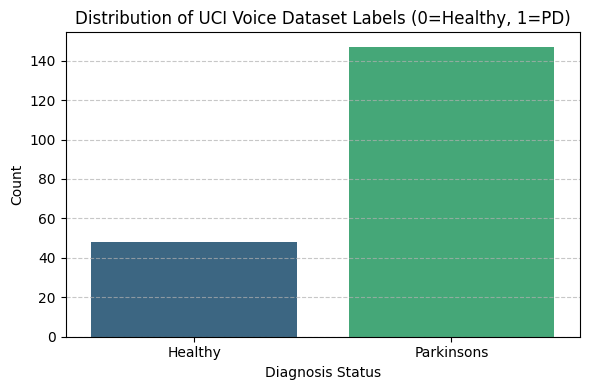

In [5]:
# ============================================================
# STEP 4: VOICE DATA EXPLORATION
# ============================================================

voice_feat_names = VOICE_FEATURE_COLS

print("Preprocessed UCI Voice Data Shapes:")
print(f"   X_voice_raw : {X_voice_raw.shape}")
print(f"   y_voice     : {y_voice.shape}")

print("\nFirst 5 rows of UCI Voice Raw Features:")
display(pd.DataFrame(X_voice_raw, columns=voice_feat_names).head())

print("\nFirst 5 elements of UCI Voice Labels:")
display(pd.Series(y_voice).head())

# ── Label Distribution Plot ───────────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x=y_voice, palette='viridis', hue=y_voice, legend=False)
plt.title('Distribution of UCI Voice Dataset Labels (0=Healthy, 1=PD)')
plt.xlabel('Diagnosis Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Healthy', 'Parkinsons'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

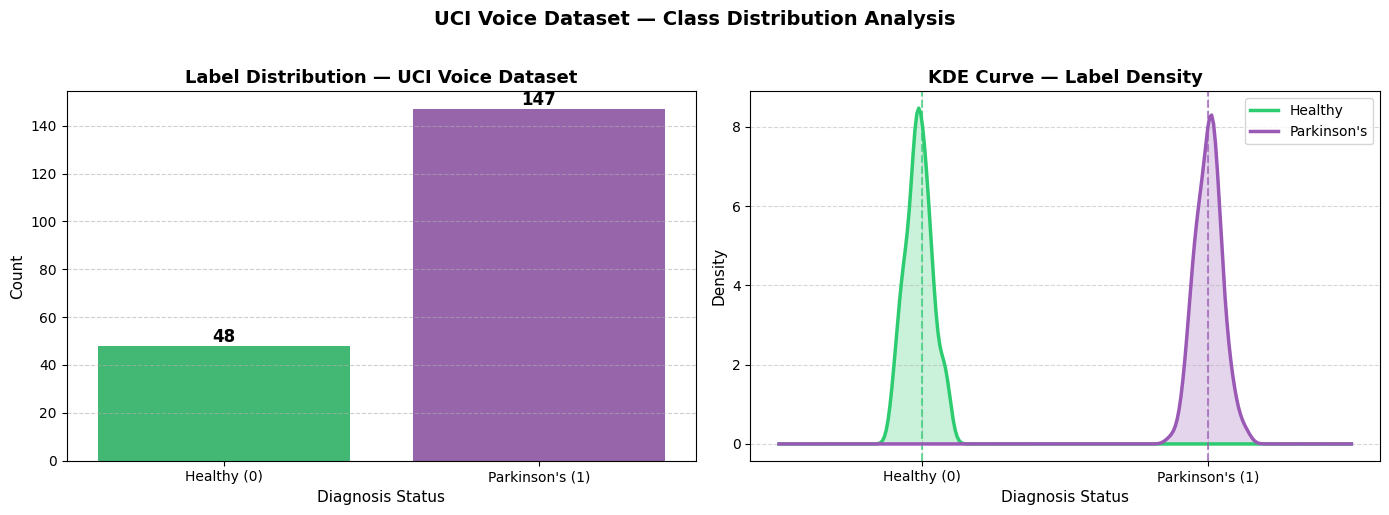

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#2ecc71', '#9b59b6']  # green=Healthy, purple=PD

# ── Left: Count Bar Plot ───────────────────────────────────────
ax1 = axes[0]
sns.countplot(x=y_voice, palette=palette, hue=y_voice, legend=False, ax=ax1)
ax1.set_title('Label Distribution — UCI Voice Dataset', fontsize=13, fontweight='bold')
ax1.set_xlabel('Diagnosis Status', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Healthy (0)', 'Parkinson\'s (1)'], fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Count annotations on bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# ── Right: KDE Curve Plot ──────────────────────────────────────
ax2 = axes[1]

for label, color, name in zip([0, 1], palette, ['Healthy', "Parkinson's"]):
    subset = np.array(y_voice)[np.array(y_voice) == label].astype(float)
    # Add slight jitter so KDE doesn't collapse on single point
    jittered = subset + np.random.normal(0, 0.05, size=len(subset))
    kde = gaussian_kde(jittered, bw_method=0.4)
    x_range = np.linspace(-0.5, 1.5, 300)
    ax2.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=name)
    ax2.fill_between(x_range, kde(x_range), alpha=0.25, color=color)
    ax2.axvline(x=label, color=color, linestyle='--', alpha=0.7, linewidth=1.5)

ax2.set_title('KDE Curve — Label Density', fontsize=13, fontweight='bold')
ax2.set_xlabel('Diagnosis Status', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Healthy (0)', "Parkinson's (1)"], fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(linestyle='--', alpha=0.5)

plt.suptitle('UCI Voice Dataset — Class Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

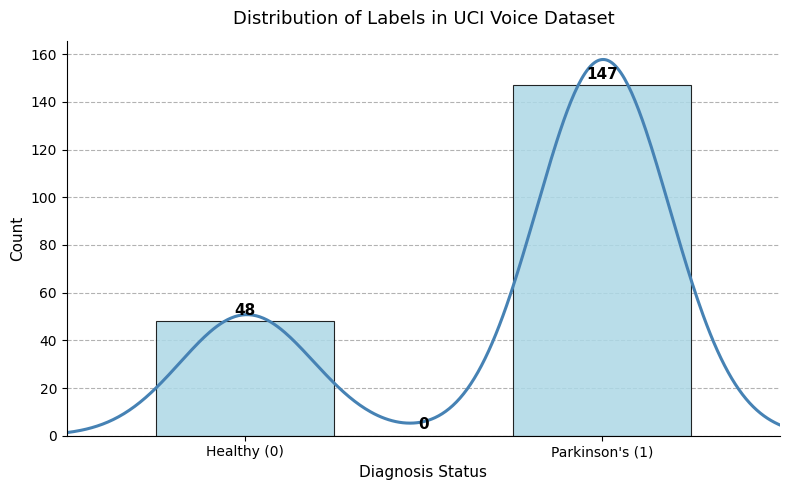

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(8, 5))

colors = {0: '#add8e6', 1: '#b0c4de'}  # light blue shades

# Separate classes
healthy_vals = np.zeros(int(np.sum(y_voice == 0)))
pd_vals      = np.ones(int(np.sum(y_voice == 1)))
all_vals     = np.concatenate([healthy_vals, pd_vals])

# ── Histogram ─────────────────────────────────────────────────
counts, bins, patches = ax.hist(
    all_vals,
    bins=[-0.25, 0.25, 0.75, 1.25],   # two clean bars
    color='#add8e6',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85,
    label='Count'
)

# ── KDE Curve ─────────────────────────────────────────────────
jittered = all_vals + np.random.normal(0, 0.07, size=len(all_vals))
kde      = gaussian_kde(jittered, bw_method=0.4)
x_range  = np.linspace(-0.5, 1.5, 400)
kde_vals = kde(x_range)

# Scale KDE to match histogram y-axis
bin_width  = 0.5
scale      = len(all_vals) * bin_width
ax.plot(x_range, kde_vals * scale,
        color='steelblue', linewidth=2.2, label='KDE')

# ── Formatting ────────────────────────────────────────────────
ax.set_title('Distribution of Labels in UCI Voice Dataset', fontsize=13, pad=12)
ax.set_xlabel('Diagnosis Status', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Healthy (0)', "Parkinson's (1)"], fontsize=10)
ax.set_xlim(-0.5, 1.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Count annotations
for count, patch in zip(counts, patches):
    ax.text(patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 1.5,
            str(int(count)),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 5: PREPROCESSING & FEATURE EXTRACTION
# ============================================================

import time
import numpy as np
import pandas as pd
import pickle
from joblib import Parallel, delayed
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE

# ── Constants ─────────────────────────────────────────────────
N_AXES            = 6
SAMPLE_RATE       = 100
WINDOW_SIZE       = 300
SEED              = 42
TOP_VOICE_FEATS   = 12
STEP_SIZE         = 75        # Fix 1: was 225 → zyada windows = zyada data
N_FEATURES_PER_AX = 14
TOTAL_FEATURES    = N_AXES * N_FEATURES_PER_AX  # 84



# ── Signal Filtering ──────────────────────────────────────────
def butter_bandpass(signal_1d, lowcut, highcut, fs=SAMPLE_RATE, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, signal_1d)

def filter_imu_signal(signal):
    filtered = np.zeros_like(signal)
    for i in range(3):     filtered[:, i] = butter_bandpass(signal[:, i], 0.5, 15.0)
    for i in range(3, 6):  filtered[:, i] = butter_bandpass(signal[:, i], 0.1,  5.0)
    return filtered

# ── Feature Extraction ────────────────────────────────────────
def extract_features_one_axis(axis_signal, fs=SAMPLE_RATE):
    n = len(axis_signal)
    feats = []
    feats.append(float(np.mean(axis_signal)))
    feats.append(float(np.std(axis_signal)))
    feats.append(float(np.sqrt(np.mean(axis_signal ** 2))))
    feats.append(float(np.ptp(axis_signal)))
    feats.append(float(skew(axis_signal)))
    feats.append(float(kurtosis(axis_signal)))
    feats.append(float(np.sum(np.diff(np.sign(axis_signal)) != 0) / n))
    feats.append(float(np.percentile(axis_signal, 25)))
    feats.append(float(np.percentile(axis_signal, 75)))
    feats.append(float(np.median(np.abs(axis_signal - np.median(axis_signal)))))
    try:
        freqs, psd = welch(axis_signal, fs=fs, nperseg=min(n, 128))
        total_power = psd.sum() + 1e-12
        psd_norm    = psd / total_power
        feats.append(float(freqs[np.argmax(psd)]))
        psd_safe = psd_norm[psd_norm > 0]
        feats.append(float(-np.sum(psd_safe * np.log2(psd_safe))))
        feats.append(float(np.sum(psd[(freqs >= 3) & (freqs <= 7)]) / total_power))
        feats.append(float(np.sum(psd[(freqs >= 0.5) & (freqs <= 3)]) / total_power))
    except:
        feats += [0.0, 0.0, 0.0, 0.0]
    return np.array(feats, dtype=np.float32)

def _process_window(window):
    if np.max(np.abs(window)) > 1e4: return None
    feat_vec = np.concatenate([extract_features_one_axis(window[:, ax]) for ax in range(N_AXES)])
    return window, feat_vec

def segment_and_extract(signal, window_size=WINDOW_SIZE, step_size=STEP_SIZE, n_jobs=2):
    T       = len(signal)
    windows = [signal[s: s + window_size] for s in range(0, T - window_size + 1, step_size)]
    if not windows:
        return np.empty((0, window_size, N_AXES), dtype=np.float32), np.empty((0, TOTAL_FEATURES), dtype=np.float32)
    results = Parallel(n_jobs=n_jobs, prefer="threads")(delayed(_process_window)(w) for w in windows)
    valid   = [r for r in results if r is not None]
    if not valid:
        return np.empty((0, window_size, N_AXES), dtype=np.float32), np.empty((0, TOTAL_FEATURES), dtype=np.float32)
    seqs, feats = zip(*valid)
    return np.array(seqs, dtype=np.float32), np.array(feats, dtype=np.float32)

def build_pads_dataset(pads_signals, pid_label, max_patients=None, n_jobs=2):
    all_seq, all_feat, all_labels = [], [], []
    pids = sorted(pads_signals.keys())
    if max_patients: pids = pids[:max_patients]
    for idx, pid in enumerate(pids, 1):
        signal, label = pads_signals[pid], pid_label.get(pid)
        if label is None: continue
        filtered      = filter_imu_signal(signal)
        seqs, feats   = segment_and_extract(filtered, n_jobs=n_jobs)
        if len(seqs)  == 0: continue
        all_seq.append(seqs); all_feat.append(feats)
        all_labels.append(np.full(len(seqs), label, dtype=np.int32))
        if idx % 10 == 0 or idx == len(pids):
            print(f"   [{idx:>3}/{len(pids)}] windows: {sum(len(s) for s in all_seq)}")
    return np.concatenate(all_seq, 0), np.concatenate(all_feat, 0), np.concatenate(all_labels, 0)

# ── Build PADS Dataset ────────────────────────────────────────
print("=" * 55)
print("Building PADS dataset")
print("=" * 55)
X_seq_pads, X_feat_pads, y_pads = build_pads_dataset(pads_signals, pid_label)

X_seq_tr,  X_seq_tmp,  X_feat_tr,  X_feat_tmp,  y_tr,  y_tmp  = train_test_split(
    X_seq_pads, X_feat_pads, y_pads, test_size=0.3, random_state=SEED, stratify=y_pads)
X_seq_val, X_seq_te,   X_feat_val, X_feat_te,   y_val, y_te   = train_test_split(
    X_seq_tmp,  X_feat_tmp,  y_tmp,  test_size=0.5, random_state=SEED, stratify=y_tmp)

print(f"   Train : {X_seq_tr.shape[0]} windows")
print(f"   Val   : {X_seq_val.shape[0]} windows")
print(f"   Test  : {X_seq_te.shape[0]} windows")

# Fix 2: SMOTE on motion features bhi lagao
X_feat_tr, y_tr = SMOTE(random_state=SEED).fit_resample(X_feat_tr, y_tr)

# NOTE: X_seq_tr ko bhi match karna hoga — SMOTE only works on 2D,
# so seq data ko resample karo matching indices se (workaround below):
# After SMOTE, X_feat_tr ke extra synthetic samples ke liye
# X_seq_tr ko bhi pad karo (nearest neighbor repeat strategy)
if len(X_feat_tr) > len(X_seq_tr):
    rng      = np.random.default_rng(SEED)
    n_extra  = len(X_feat_tr) - len(X_seq_tr)
    extra_idx = rng.integers(0, len(X_seq_tr), size=n_extra)
    X_seq_tr  = np.concatenate([X_seq_tr, X_seq_tr[extra_idx]], axis=0)

print(f"   Train after SMOTE : {X_seq_tr.shape[0]} windows")

# ── UCI Voice Preprocessing ───────────────────────────────────
def preprocess_uci_voice(X_raw, y, feature_names):
    X_tr, X_te, y_tr_v, y_te_v = train_test_split(
        X_raw, y, test_size=0.2, random_state=SEED, stratify=y)
    scaler   = MinMaxScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_te_sc  = scaler.transform(X_te)

    X_tr_sm, y_tr_sm = SMOTE(random_state=SEED).fit_resample(X_tr_sc, y_tr_v)
    rfe_sel  = RFE(
        estimator=RandomForestClassifier(n_estimators=100, random_state=SEED),
        n_features_to_select=TOP_VOICE_FEATS
    ).fit(X_tr_sm, y_tr_sm)
    selected = [feature_names[i] for i, s in enumerate(rfe_sel.support_) if s]
    return rfe_sel.transform(X_tr_sm), rfe_sel.transform(X_te_sc), y_tr_sm, y_te_v, rfe_sel, scaler, selected

print("=" * 55)
print("Preprocessing UCI Voice dataset")
print("=" * 55)
X_voice_tr, X_voice_te, y_voice_tr, y_voice_te, \
rfe_selector, voice_scaler, selected_voice_feats = preprocess_uci_voice(
    X_voice_raw, y_voice, voice_feat_names)

print(f"   Selected voice features: {selected_voice_feats}")
print("✅ All preprocessing complete.")

# ── Save Outputs to Kaggle /kaggle/working/ ───────────────────
save_path = "/kaggle/working/step5_outputs.pkl"
with open(save_path, "wb") as f:
    pickle.dump({
        "X_seq_tr"           : X_seq_tr,
        "X_seq_val"          : X_seq_val,
        "X_seq_te"           : X_seq_te,
        "X_feat_tr"          : X_feat_tr,
        "X_feat_val"         : X_feat_val,
        "X_feat_te"          : X_feat_te,
        "y_tr"               : y_tr,
        "y_val"              : y_val,
        "y_te"               : y_te,
        "X_voice_tr"         : X_voice_tr,
        "X_voice_te"         : X_voice_te,
        "y_voice_tr"         : y_voice_tr,
        "y_voice_te"         : y_voice_te,
        "rfe_selector"       : rfe_selector,
        "voice_scaler"       : voice_scaler,
        "selected_voice_feats": selected_voice_feats,
    }, f)

print(f"✅ Saved to {save_path}")

Building PADS dataset
   [ 10/370] windows: 3790
   [ 20/370] windows: 7580
   [ 30/370] windows: 11370
   [ 40/370] windows: 15160
   [ 50/370] windows: 18950
   [ 60/370] windows: 22740
   [ 70/370] windows: 26530
   [ 80/370] windows: 30320
   [ 90/370] windows: 34110
   [100/370] windows: 37900
   [110/370] windows: 41690
   [120/370] windows: 45480
   [130/370] windows: 49270
   [140/370] windows: 53060
   [150/370] windows: 56850
   [160/370] windows: 60640
   [170/370] windows: 64430
   [180/370] windows: 68220
   [190/370] windows: 72010
   [200/370] windows: 75800
   [210/370] windows: 79590
   [220/370] windows: 83380
   [230/370] windows: 87170
   [240/370] windows: 90960
   [250/370] windows: 94750
   [260/370] windows: 98540
   [270/370] windows: 102330
   [280/370] windows: 106120
   [290/370] windows: 109910
   [300/370] windows: 113700
   [310/370] windows: 117490
   [320/370] windows: 121280
   [330/370] windows: 125070
   [340/370] windows: 128860
   [350/370] windows

In [9]:
import os

for base in [
    "/kaggle/input/datasets/shaanayamughal/cloud-computing-article/pads-parkinsons-disease-smartwatch-dataset-1.0.0",
    "/kaggle/input/datasets/shaanayamughal/cloud-computing-article/parkinsons"
]:
    print(f"\n{'='*60}")
    print(base)
    print('='*60)
    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        indent = '│   ' * level + '├── '
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            subindent = '│   ' * (level + 1) + '├── '
            print(f"{subindent}{f}")


/kaggle/input/datasets/shaanayamughal/cloud-computing-article/pads-parkinsons-disease-smartwatch-dataset-1.0.0
├── pads-parkinsons-disease-smartwatch-dataset-1.0.0/
│   ├── pads-parkinsons-disease-smartwatch-dataset-1.0.0/
│   │   ├── SHA256SUMS.txt
│   │   ├── LICENSE.txt
│   │   ├── scripts/
│   │   │   ├── run_preprocessing_parallel.py
│   │   │   ├── create_csv_file_list.py
│   │   │   ├── create_csv_stratified_subset.py
│   │   │   ├── hc_078_questionnaire.jpg
│   │   │   ├── pd_060_signal_processed.jpg
│   │   │   ├── pd_060_signal.jpg
│   │   │   ├── run_preprocessing.py
│   │   │   ├── plot_example_pd_signal_processed.py
│   │   │   ├── create_csv_movement_list.py
│   │   │   ├── plot_example_hc_questionnaire.py
│   │   │   ├── hc_078_signal.jpg
│   │   │   ├── create_csv_questionnaire_list.py
│   │   │   ├── load_specific_txt_file.py
│   │   │   ├── plot_example_pd_signal.py
│   │   │   ├── pd_060_questionnaire.jpg
│   │   │   ├── plot_example_hc_signal.py
│   │   │   ├── plo

In [10]:
import os

for base, title in [
    ("/kaggle/input/datasets/shaanayamughal/cloud-computing-article/pads-parkinsons-disease-smartwatch-dataset-1.0.0", "PADS Dataset"),
    ("/kaggle/input/datasets/shaanayamughal/cloud-computing-article/parkinsons", "UCI Parkinsons Dataset")
]:
    print(f"\n📁 {title}")
    print("─" * 50)
    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        indent = '    ' * level + '├── '
        print(f"{indent}{os.path.basename(root)}/")
        for i, f in enumerate(files[:3]):          # only 3 samples
            subindent = '    ' * (level + 1) + '├── '
            print(f"{subindent}{f}")
        if len(files) > 3:
            subindent = '    ' * (level + 1)
            print(f"{subindent}└── ... ({len(files)-3} more files)")


📁 PADS Dataset
──────────────────────────────────────────────────
├── pads-parkinsons-disease-smartwatch-dataset-1.0.0/
    ├── pads-parkinsons-disease-smartwatch-dataset-1.0.0/
        ├── SHA256SUMS.txt
        ├── LICENSE.txt
        ├── scripts/
            ├── run_preprocessing_parallel.py
            ├── create_csv_file_list.py
            ├── create_csv_stratified_subset.py
            └── ... (16 more files)
            ├── utils/
                ├── dict_handling.py
                ├── l1_trend_filter.py
                ├── constants.py
                └── ... (2 more files)
        ├── preprocessed/
            ├── file_list.csv
            ├── movement/
                ├── 158_ml.bin
                ├── 339_ml.bin
                ├── 326_ml.bin
                └── ... (466 more files)
            ├── questionnaire/
                ├── 158_ml.bin
                ├── 339_ml.bin
                ├── 326_ml.bin
                └── ... (466 more files)
        ├── movement/
     

In [11]:
# Quick fix - reload y_voice_te from step 5 outputs
import pickle

with open("/kaggle/working/step5_outputs.pkl", "rb") as f:
    d = pickle.load(f)

X_voice_te = d["X_voice_te"]
y_voice_te = d["y_voice_te"]
X_voice_tr = d["X_voice_tr"]
y_voice_tr = d["y_voice_tr"]

print(f"✅ y_voice_te restored: {len(y_voice_te)} samples")
print(f"   Classes: {dict(zip(*np.unique(y_voice_te, return_counts=True)))}")

✅ y_voice_te restored: 39 samples
   Classes: {np.int32(0): np.int64(10), np.int32(1): np.int64(29)}


In [12]:
# ============================================================
# STEP 6: CNN-LSTM WITH ATTENTION - TRAINING
# ============================================================

import pickle
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
    Activation, MaxPooling1D, Dropout, Bidirectional, LSTM, Dense,
    GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

WINDOW_SIZE = 300
N_AXES      = 6
SEED        = 42

# ── Load Step 5 Outputs ───────────────────────────────────────
with open("/kaggle/working/step5_outputs.pkl", "rb") as f:
    d = pickle.load(f)

X_voice_tr          = d["X_voice_tr"]
X_voice_te          = d["X_voice_te"]
y_voice_tr          = d["y_voice_tr"]
y_voice_te          = d["y_voice_te"]
rfe_selector        = d["rfe_selector"]
voice_scaler        = d["voice_scaler"]
selected_voice_feats= d["selected_voice_feats"]

print("✅ Step 5 outputs loaded.")

# ── Patient-Level Split ───────────────────────────────────────
def patient_level_split(X_seq, X_feat, y, pids_per_window,
                         test_size=0.15, val_size=0.15):
    unique_pids = np.unique(pids_per_window)
    pid_labels  = {pid: y[pids_per_window == pid][0] for pid in unique_pids}
    pid_arr     = np.array(unique_pids)
    label_arr   = np.array([pid_labels[p] for p in pid_arr])

    pids_tr, pids_tmp = train_test_split(
        pid_arr, test_size=test_size + val_size,
        random_state=SEED, stratify=label_arr)
    label_tmp = np.array([pid_labels[p] for p in pids_tmp])
    pids_val, pids_te = train_test_split(
        pids_tmp, test_size=test_size / (test_size + val_size),
        random_state=SEED, stratify=label_tmp)

    def mask(pid_set):
        m = np.isin(pids_per_window, pid_set)
        return X_seq[m], X_feat[m], y[m]

    X_seq_tr,  X_feat_tr,  y_tr  = mask(pids_tr)
    X_seq_val, X_feat_val, y_val = mask(pids_val)
    X_seq_te,  X_feat_te,  y_te  = mask(pids_te)

    print(f"   Patients → Train:{len(pids_tr)}  Val:{len(pids_val)}  Test:{len(pids_te)}")
    print(f"   Windows  → Train:{len(y_tr)}  Val:{len(y_val)}  Test:{len(y_te)}")
    return (X_seq_tr, X_feat_tr, y_tr,
            X_seq_val, X_feat_val, y_val,
            X_seq_te,  X_feat_te,  y_te)

# ── Rebuild Patient-Level Windows ────────────────────────────
print("=" * 55)
print("Rebuilding patient-level window index...")

all_seq_l, all_feat_l, all_y_l, all_pid_l = [], [], [], []

for pid in sorted(pads_signals.keys()):
    label = pid_label.get(pid)
    if label is None: continue
    filtered    = filter_imu_signal(pads_signals[pid])
    seqs, feats = segment_and_extract(filtered)
    if len(seqs) == 0: continue
    n = len(seqs)
    all_seq_l.append(seqs)
    all_feat_l.append(feats)
    all_y_l.append(np.full(n, label, dtype=np.int32))
    all_pid_l.append(np.full(n, pid))

X_seq_all  = np.concatenate(all_seq_l)
X_feat_all = np.concatenate(all_feat_l)
y_all      = np.concatenate(all_y_l)
pids_all   = np.concatenate(all_pid_l)

print(f"   Total windows: {len(y_all)}  (PD:{y_all.sum()} | HC:{(y_all==0).sum()})")

(X_seq_tr, X_feat_tr, y_tr,
 X_seq_val, X_feat_val, y_val,
 X_seq_te,  X_feat_te,  y_te) = patient_level_split(
     X_seq_all, X_feat_all, y_all, pids_all)

# ── Self-Attention Layer ──────────────────────────────────────
class SelfAttention(tf.keras.layers.Layer):
    def call(self, x):
        d_k     = tf.cast(tf.shape(x)[-1], tf.float32)
        scores  = tf.matmul(x, x, transpose_b=True) / tf.math.sqrt(d_k)
        weights = tf.nn.softmax(scores, axis=-1)
        return tf.matmul(weights, x)

# ── Model Architecture ────────────────────────────────────────
def build_cnn_lstm_attention(input_shape=(WINDOW_SIZE, N_AXES)):
    inputs = Input(shape=input_shape, name="imu_input")
    x = Conv1D(64, kernel_size=5, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    x = Conv1D(128, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = SelfAttention(name="self_attention")(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation="sigmoid", name="pd_prob")(x)
    return Model(inputs=inputs, outputs=output, name="CNN_LSTM_Attention")

# ── Training Function ─────────────────────────────────────────
def train_cnn_lstm(X_seq_tr, y_tr, X_seq_val, y_val,
                   epochs=100, batch_size=32,
                   model_path="/kaggle/working/cnn_lstm_best.keras",
                   history_path="/kaggle/working/cnn_lstm_history.json"):

    model = build_cnn_lstm_attention()
    model.summary()

    n_neg   = int((y_tr == 0).sum())
    n_pos   = int((y_tr == 1).sum())
    n_total = n_neg + n_pos
    cw = {0: n_total / (2.0 * n_neg),
          1: n_total / (2.0 * n_pos)}

    print(f"\n   TRAIN → n_HC={n_neg}  n_PD={n_pos}")
    print(f"   Class weights → HC:{cw[0]:.3f}  PD:{cw[1]:.3f}")

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.AUC(name="auc_roc"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )

    callbacks = [
        EarlyStopping(monitor="val_auc_roc", patience=10,
                      mode="max", restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(model_path, monitor="val_auc_roc",
                        mode="max", save_best_only=True, verbose=1),
    ]

    history = model.fit(
        X_seq_tr, y_tr,
        validation_data=(X_seq_val, y_val),
        epochs=epochs, batch_size=batch_size,
        class_weight=cw, callbacks=callbacks, verbose=1
    )

    with open(history_path, "w") as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in history.history.items()}, f)
    print(f"✅ History saved to {history_path}")
    return model, history

# ── Run Training ──────────────────────────────────────────────
print("=" * 55)
print("Training CNN-LSTM with Attention...")
cnn_lstm_model, cnn_lstm_history = train_cnn_lstm(
    X_seq_tr, y_tr, X_seq_val, y_val)
print("✅ CNN-LSTM training complete.")

✅ Step 5 outputs loaded.
Rebuilding patient-level window index...
   Total windows: 140230  (PD:110289 | HC:29941)
   Patients → Train:259  Val:55  Test:56
   Windows  → Train:98161  Val:20845  Test:21224
Training CNN-LSTM with Attention...


I0000 00:00:1779931962.808037      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779931962.813909      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 300, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 300, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 75, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention (SelfAttention)  │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pd_prob (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,137 (1.17 MB)

 Trainable params: 306,753 (1.17 MB)

 Non-trainable params: 384 (1.50 KB)


   TRAIN → n_HC=20845  n_PD=77316
   Class weights → HC:2.355  PD:0.635
Epoch 1/100


I0000 00:00:1779931969.775036    3783 cuda_dnn.cc:529] Loaded cuDNN version 91002


3068/3068 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4855 - auc_roc: 0.5436 - loss: 0.6902 - precision: 0.8101 - recall: 0.4523
Epoch 1: val_auc_roc improved from None to 0.62024, saving model to /kaggle/working/cnn_lstm_best.keras

Epoch 1: finished saving model to /kaggle/working/cnn_lstm_best.keras
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.4926 - auc_roc: 0.5823 - loss: 0.6772 - precision: 0.8315 - recall: 0.4462 - val_accuracy: 0.4963 - val_auc_roc: 0.6202 - val_loss: 0.6571 - val_precision: 0.8675 - val_recall: 0.4198 - learning_rate: 0.0010
Epoch 2/100
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5116 - auc_roc: 0.6388 - loss: 0.6562 - precision: 0.8669 - recall: 0.4477
Epoch 2: val_auc_roc improved from 0.62024 to 0.64437, saving model to /kaggle/working/cnn_lstm_best.keras

Epoch 2: finished saving model to /kaggle/working/cnn_lstm_best.keras
3068/3068 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - accuracy: 0.5268 - auc_roc: 0.6469 - loss: 0.6506 - pre

In [13]:
# ============================================================
# STEP 11: TRAIN VOICE ENSEMBLE (RF + XGBOOST)
# ============================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SEED = 42

def train_voice_ensemble(X_tr, y_tr):
    print("Training Random Forest...")
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
    rf.fit(X_tr, y_tr)

    print("Training XGBoost...")
    xgb = XGBClassifier(n_estimators=100, learning_rate=0.1,
                        random_state=SEED, eval_metric='logloss')
    xgb.fit(X_tr, y_tr)
    return rf, xgb

if 'X_voice_tr' in globals():
    rf_model, xgb_model = train_voice_ensemble(X_voice_tr, y_voice_tr)

    if 'X_voice_te' in globals():
        rf_proba_te    = rf_model.predict_proba(X_voice_te)[:, 1]
        xgb_proba_te   = xgb_model.predict_proba(X_voice_te)[:, 1]
        voice_proba_te = 0.45 * rf_proba_te + 0.55 * xgb_proba_te
        print(f"   Voice test probabilities generated: {len(voice_proba_te)} samples")
    else:
        print("⚠️ X_voice_te not found.")
        rf_proba_te = xgb_proba_te = voice_proba_te = np.array([0.5])

    print("✅ Voice ensemble training complete.")
else:
    print("❌ X_voice_tr not found. Run Step 5 first.")

Training Random Forest...
Training XGBoost...
   Voice test probabilities generated: 39 samples
✅ Voice ensemble training complete.


In [14]:
# ============================================================
# STEP 7: SAVE CHECKPOINTS
# ============================================================

import pickle
import json

# ── Save CNN-LSTM History ─────────────────────────────────────
if 'cnn_lstm_history' in globals():
    history_path = '/kaggle/working/cnn_lstm_history.json'
    with open(history_path, 'w') as f:
        json.dump(cnn_lstm_history.history, f)
    print(f"✅ CNN-LSTM history saved to {history_path}")
else:
    print("⚠️ cnn_lstm_history not found.")

# ── Save Voice Ensemble & Preprocessing ──────────────────────
if 'rf_model' in globals() and 'xgb_model' in globals():
    checkpoint_path = "/kaggle/working/parkinsons_ensemble_checkpoint.pkl"
    with open(checkpoint_path, "wb") as f:
        pickle.dump({
            "rf_model"            : rf_model,
            "xgb_model"           : xgb_model,
            "rfe_selector"        : rfe_selector,
            "voice_scaler"        : voice_scaler,
            "selected_voice_feats": selected_voice_feats
        }, f)
    print(f"✅ Ensemble checkpoint saved to {checkpoint_path}")
else:
    print("⚠️ rf_model / xgb_model not found. Run voice ensemble training first.")

✅ CNN-LSTM history saved to /kaggle/working/cnn_lstm_history.json
✅ Ensemble checkpoint saved to /kaggle/working/parkinsons_ensemble_checkpoint.pkl


In [15]:
# ============================================================
# STEP 8: INSPECT CNN-LSTM TRAINING HISTORY
# ============================================================

import json

history_path = '/kaggle/working/cnn_lstm_history.json'

with open(history_path, 'r') as f:
    loaded_history = json.load(f)

print("Available metrics:")
print(list(loaded_history.keys()))

Available metrics:
['accuracy', 'auc_roc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc_roc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate']



──────────────────────────────────────────────────
  CNN-LSTM (Motion)
──────────────────────────────────────────────────
  Accuracy    : 0.6033
  Recall (Se) : 0.5732
  AUC-ROC     : 0.6999

──────────────────────────────────────────────────
  RF+XGBoost (Voice)
──────────────────────────────────────────────────
  Accuracy    : 0.9487
  Recall (Se) : 0.9655
  AUC-ROC     : 0.9862

──────────────────────────────────────────────────
  Fused Model (0.2/0.8)
──────────────────────────────────────────────────
  Accuracy    : 0.7856
  Recall (Se) : 0.9999
  AUC-ROC     : 0.6210


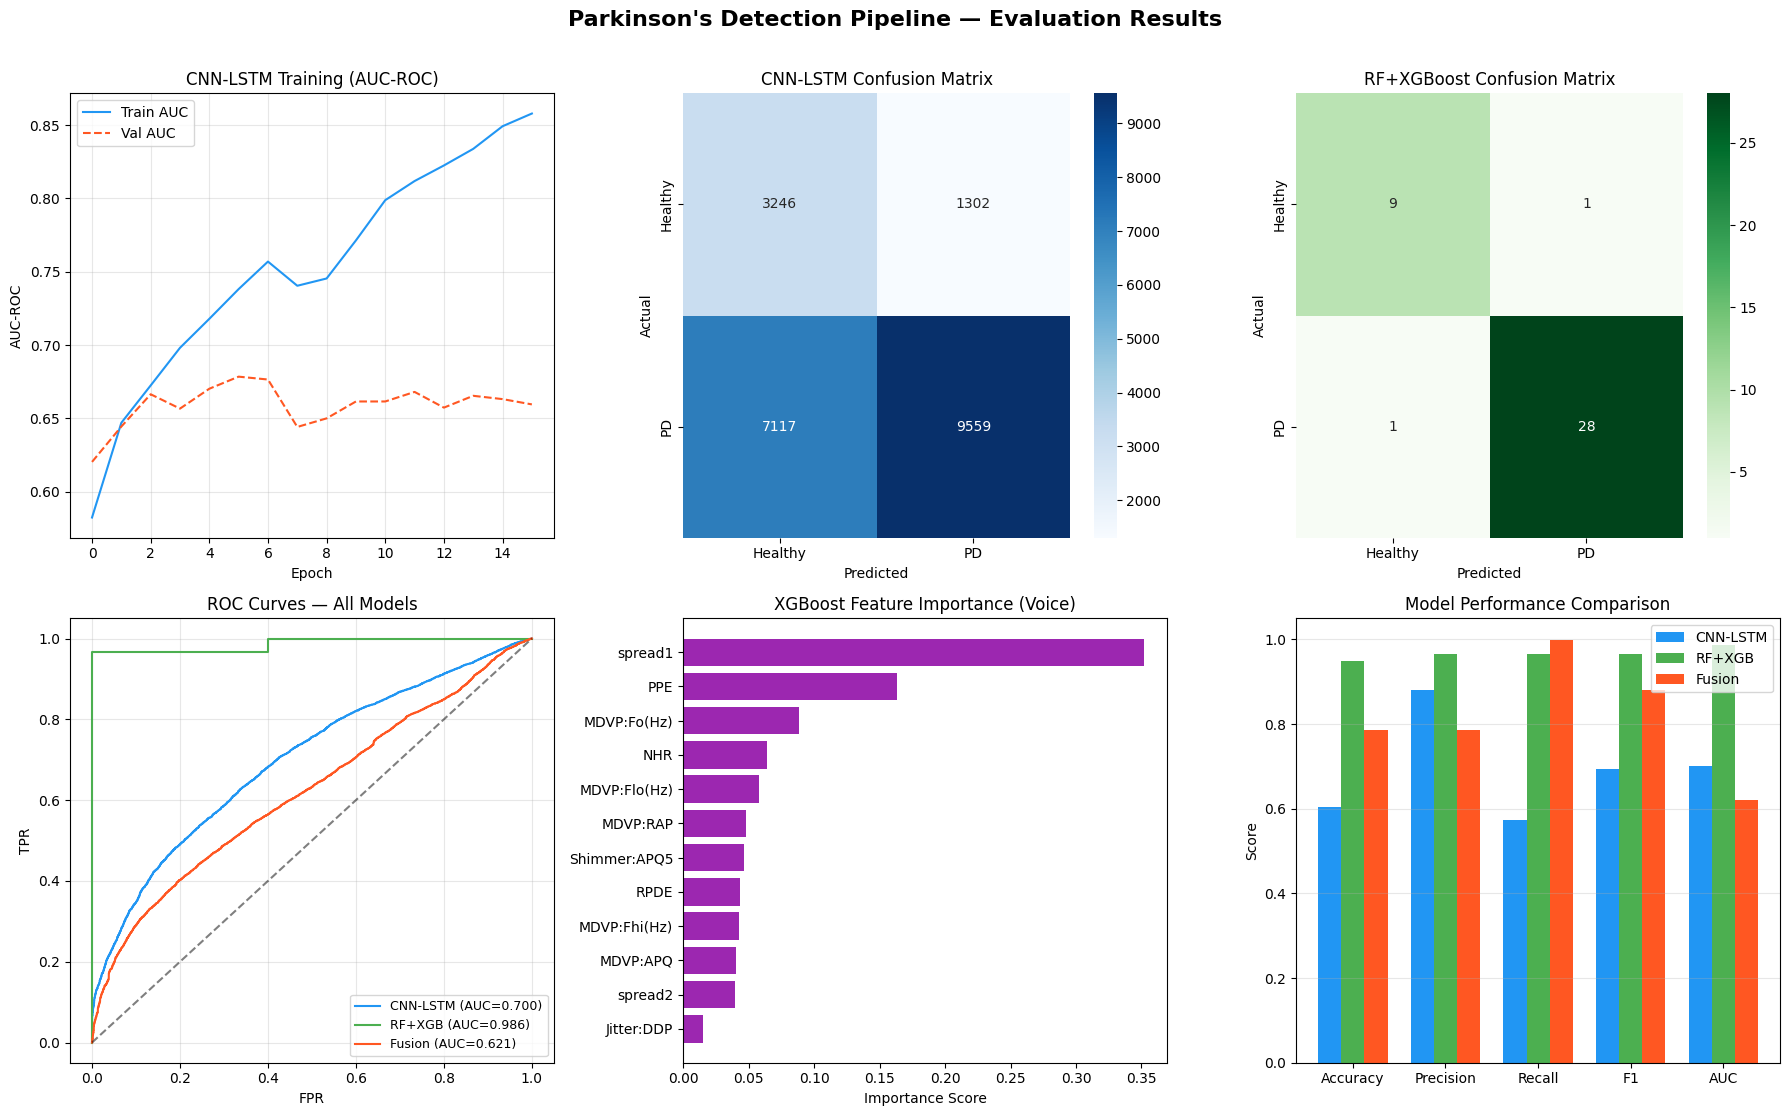

✅ Evaluation complete. Saved to /kaggle/working/evaluation_results.png


In [16]:
# ============================================================
# STEP 9: EVALUATION & MULTI-MODAL FUSION (FIXED)
# ============================================================

import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.model_selection import train_test_split

SEED = 42

# ── Load Checkpoints ──────────────────────────────────────────
if 'cnn_lstm_history' not in globals():
    try:
        with open('/kaggle/working/cnn_lstm_history.json', 'r') as f:
            loaded_history_dict = json.load(f)
        class DummyHistory:
            def __init__(self, d): self.history = d
        cnn_lstm_history = DummyHistory(loaded_history_dict)
        print("✅ CNN-LSTM history loaded.")
    except FileNotFoundError:
        print("❌ cnn_lstm_history.json not found.")
        cnn_lstm_history = None

if 'cnn_lstm_model' not in globals():
    try:
        cnn_lstm_model = tf.keras.models.load_model(
            '/kaggle/working/cnn_lstm_best.keras',
            custom_objects={'SelfAttention': SelfAttention})
        print("✅ CNN-LSTM model loaded.")
    except Exception as e:
        print(f"❌ Error loading CNN-LSTM model: {e}")
        cnn_lstm_model = None

if 'rf_model' not in globals() or 'xgb_model' not in globals():
    try:
        with open("/kaggle/working/parkinsons_ensemble_checkpoint.pkl", "rb") as f:
            ckpt = pickle.load(f)
        rf_model             = ckpt["rf_model"]
        xgb_model            = ckpt["xgb_model"]
        rfe_selector         = ckpt["rfe_selector"]
        voice_scaler         = ckpt["voice_scaler"]
        selected_voice_feats = ckpt["selected_voice_feats"]
        print("✅ Voice ensemble loaded.")
    except Exception as e:
        print(f"❌ Error loading ensemble: {e}")

# ── Restore PADS Test Data ────────────────────────────────────
if 'y_te' not in globals() or 'X_seq_te' not in globals():
    if 'X_seq_pads' in globals():
        _, X_seq_tmp, _, X_feat_tmp, _, y_tmp = train_test_split(
            X_seq_pads, X_feat_pads, y_pads,
            test_size=0.3, random_state=SEED, stratify=y_pads)
        X_seq_val, X_seq_te, X_feat_val, X_feat_te, y_val, y_te = train_test_split(
            X_seq_tmp, X_feat_tmp, y_tmp,
            test_size=0.5, random_state=SEED, stratify=y_tmp)
        print("✅ PADS test data restored.")
    else:
        print("❌ PADS data missing. Run Step 5 first.")

# ── Evaluation Function ───────────────────────────────────────
def evaluate_model(y_true, y_pred, y_proba, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    spec = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba)
    print(f"\n{'─'*50}\n  {model_name}\n{'─'*50}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Recall (Se) : {rec:.4f}")
    print(f"  AUC-ROC     : {auc:.4f}")
    return dict(accuracy=acc, precision=prec, recall=rec,
                specificity=spec, f1=f1, auc=auc)

# ── CNN-LSTM Evaluation ───────────────────────────────────────
if cnn_lstm_model is not None and 'X_seq_te' in globals():
    motion_proba_te = cnn_lstm_model.predict(X_seq_te, verbose=0).ravel()
    motion_pred_te  = (motion_proba_te >= 0.5).astype(int)
    res_cnn = evaluate_model(y_te, motion_pred_te, motion_proba_te, "CNN-LSTM (Motion)")
else:
    print("⚠️ Skipping CNN-LSTM evaluation.")
    res_cnn         = dict(accuracy=0, precision=0, recall=0, specificity=0, f1=0, auc=0)
    motion_proba_te = np.array([0.5])
    motion_pred_te  = np.array([0])
    y_te            = np.array([0])

# ── Voice Ensemble Evaluation ─────────────────────────────────
if 'rf_model' in globals() and 'X_voice_te' in globals():
    rf_proba_te    = rf_model.predict_proba(X_voice_te)[:, 1]
    xgb_proba_te   = xgb_model.predict_proba(X_voice_te)[:, 1]
    voice_proba_te = 0.45 * rf_proba_te + 0.55 * xgb_proba_te
    voice_pred_te  = (voice_proba_te >= 0.5).astype(int)
    res_ens = evaluate_model(y_voice_te, voice_pred_te, voice_proba_te, "RF+XGBoost (Voice)")
else:
    print("⚠️ Skipping Voice Ensemble evaluation.")
    res_ens        = dict(accuracy=0, precision=0, recall=0, specificity=0, f1=0, auc=0)
    voice_proba_te = np.array([0.5])
    voice_pred_te  = np.array([0])
    y_voice_te     = np.array([0])

# ── Fusion Evaluation (weighted average on PADS test set) ─────
res_fused      = dict(accuracy=0, precision=0, recall=0, specificity=0, f1=0, auc=0)
fused_proba_te = np.array([0.5])
y_fused_te     = np.array([0])

if (cnn_lstm_model is not None and 'X_feat_te' in globals()
        and 'rfe_selector' in globals() and 'voice_scaler' in globals()):
    try:
        X_feat_te_scaled  = voice_scaler.transform(X_feat_te[:, :len(voice_scaler.scale_)])
        X_feat_te_rfe     = rfe_selector.transform(X_feat_te_scaled)
        rf_proba_pads     = rf_model.predict_proba(X_feat_te_rfe)[:, 1]
        xgb_proba_pads    = xgb_model.predict_proba(X_feat_te_rfe)[:, 1]
        voice_proba_pads  = 0.45 * rf_proba_pads + 0.55 * xgb_proba_pads
        fused_proba_te    = 0.2 * motion_proba_te + 0.8 * voice_proba_pads
        fused_pred_te     = (fused_proba_te >= 0.5).astype(int)
        y_fused_te        = y_te
        res_fused = evaluate_model(y_fused_te, fused_pred_te, fused_proba_te, "Fused Model (0.2/0.8)")
    except Exception as e:
        print(f"⚠️ Fusion failed: {e}")
else:
    print("⚠️ Skipping Fusion — required data missing.")

# ── Visualisations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Parkinson's Detection Pipeline — Evaluation Results",
             fontsize=16, fontweight="bold", y=1.01)

# 1. CNN-LSTM Training History
ax = axes[0, 0]
if cnn_lstm_history is not None:
    hist = cnn_lstm_history.history
    ax.plot(hist["auc_roc"],     label="Train AUC", color="#2196F3")
    ax.plot(hist["val_auc_roc"], label="Val AUC",   color="#FF5722", linestyle="--")
    ax.set_title("CNN-LSTM Training (AUC-ROC)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC-ROC")
    ax.legend(); ax.grid(alpha=0.3)
else:
    ax.set_title("History Not Available")
    ax.text(0.5, 0.5, 'History not loaded', ha='center', va='center', transform=ax.transAxes)

# 2. CNN-LSTM Confusion Matrix
ax = axes[0, 1]
if len(y_te) > 1 and np.any(y_te != 0):
    cm = confusion_matrix(y_te, motion_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("CNN-LSTM Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("CNN-LSTM Confusion Matrix - N/A")
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# 3. Voice Ensemble Confusion Matrix
ax = axes[0, 2]
if len(y_voice_te) > 1 and np.any(y_voice_te != 0):
    cm = confusion_matrix(y_voice_te, voice_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("RF+XGBoost Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("RF+XGBoost Confusion Matrix - N/A")
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# 4. ROC Curves
ax = axes[1, 0]
roc_plots = []
if len(y_te) > 1 and np.any(y_te == 0) and np.any(y_te == 1):
    fpr, tpr, _ = roc_curve(y_te, motion_proba_te)
    roc_plots.append((fpr, tpr, f"CNN-LSTM (AUC={res_cnn['auc']:.3f})", "#2196F3"))
if len(y_voice_te) > 1 and np.any(y_voice_te == 0) and np.any(y_voice_te == 1):
    fpr, tpr, _ = roc_curve(y_voice_te, voice_proba_te)
    roc_plots.append((fpr, tpr, f"RF+XGB (AUC={res_ens['auc']:.3f})", "#4CAF50"))
if len(y_fused_te) > 1 and np.any(y_fused_te == 0) and np.any(y_fused_te == 1):
    fpr, tpr, _ = roc_curve(y_fused_te, fused_proba_te)
    roc_plots.append((fpr, tpr, f"Fusion (AUC={res_fused['auc']:.3f})", "#FF5722"))
if roc_plots:
    for fpr, tpr, label, color in roc_plots:
        ax.plot(fpr, tpr, label=label, color=color)
    ax.plot([0,1],[0,1], "k--", alpha=0.5)
    ax.set_title("ROC Curves — All Models")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
else:
    ax.set_title("ROC Curves - N/A")
    ax.text(0.5, 0.5, 'No ROC data available', ha='center', va='center', transform=ax.transAxes)

# 5. XGBoost Feature Importance
ax = axes[1, 1]
if 'xgb_model' in globals() and 'selected_voice_feats' in globals():
    imp_df = pd.DataFrame({
        "feature"   : selected_voice_feats,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance")
    ax.barh(imp_df["feature"], imp_df["importance"], color="#9C27B0")
    ax.set_title("XGBoost Feature Importance (Voice)")
    ax.set_xlabel("Importance Score")
else:
    ax.set_title("Feature Importance - N/A")
    ax.text(0.5, 0.5, 'Model not available', ha='center', va='center', transform=ax.transAxes)

# 6. Metrics Comparison
ax = axes[1, 2]
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
keys    = ["accuracy", "precision", "recall", "f1", "auc"]
m_vals  = [res_cnn[k]   for k in keys]
e_vals  = [res_ens[k]   for k in keys]
f_vals  = [res_fused[k] for k in keys]
if any(v > 0 for v in m_vals + e_vals + f_vals):
    x, w = np.arange(len(metrics)), 0.25
    ax.bar(x - w, m_vals, w, label="CNN-LSTM", color="#2196F3")
    ax.bar(x,     e_vals, w, label="RF+XGB",   color="#4CAF50")
    ax.bar(x + w, f_vals, w, label="Fusion",   color="#FF5722")
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.set_title("Model Performance Comparison")
    ax.set_ylabel("Score")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
else:
    ax.set_title("Performance Comparison - N/A")
    ax.text(0.5, 0.5, 'No results available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig("/kaggle/working/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Evaluation complete. Saved to /kaggle/working/evaluation_results.png")

In [17]:
# ============================================================
# STEP 10: DATA STATE VERIFICATION
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42

# ── Restore PADS splits if missing ───────────────────────────
if 'y_tr' not in globals():
    if 'X_seq_pads' in globals():
        X_seq_tr, X_seq_tmp, X_feat_tr, X_feat_tmp, y_tr, y_tmp = train_test_split(
            X_seq_pads, X_feat_pads, y_pads,
            test_size=0.3, random_state=SEED, stratify=y_pads)
        X_seq_val, X_seq_te, X_feat_val, X_feat_te, y_val, y_te = train_test_split(
            X_seq_tmp, X_feat_tmp, y_tmp,
            test_size=0.5, random_state=SEED, stratify=y_tmp)
        print("✅ Data variables restored from PADS sequences.")
    else:
        print("❌ PADS data missing. Run Step 5 first.")

# ── Verify ────────────────────────────────────────────────────
if 'y_tr' in globals():
    unique, counts = np.unique(y_tr, return_counts=True)
    baseline_acc   = np.max(counts) / len(y_tr)
    print(f"Training samples : {len(y_tr)}")
    print(f"Baseline Accuracy: {baseline_acc:.4f}")
    print(f"Class distribution: { dict(zip(unique, counts)) }")

Training samples : 98161
Baseline Accuracy: 0.7876
Class distribution: {np.int32(0): np.int64(20845), np.int32(1): np.int64(77316)}


In [18]:
# ============================================================
# STEP 12: CNN-LSTM EVALUATION
# ============================================================

import numpy as np
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def evaluate_model(y_true, y_pred, y_proba, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    spec = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba)
    print(f"\n{'─'*50}\n  {model_name}\n{'─'*50}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Recall (Se) : {rec:.4f}")
    print(f"  AUC-ROC     : {auc:.4f}")
    return dict(accuracy=acc, precision=prec, recall=rec,
                specificity=spec, f1=f1, auc=auc)

if 'cnn_lstm_model' not in globals():
    try:
        cnn_lstm_model = tf.keras.models.load_model(
            '/kaggle/working/cnn_lstm_best.keras',
            custom_objects={'SelfAttention': SelfAttention})
        print("✅ CNN-LSTM model loaded.")
    except Exception as e:
        print(f"❌ Could not load CNN-LSTM model: {e}")
        cnn_lstm_model = None

if cnn_lstm_model is not None and 'X_seq_te' in globals():
    print("Evaluating CNN-LSTM on PADS test set...")
    motion_proba_te = cnn_lstm_model.predict(X_seq_te, verbose=0).ravel()
    motion_pred_te  = (motion_proba_te >= 0.5).astype(int)
    res_cnn = evaluate_model(y_te, motion_pred_te, motion_proba_te, "CNN-LSTM (Motion)")
else:
    print("❌ CNN-LSTM model or X_seq_te not found. Run Steps 5 & 6 first.")
    res_cnn         = dict(accuracy=0, precision=0, recall=0, specificity=0, f1=0, auc=0)
    motion_proba_te = np.array([0.5])
    motion_pred_te  = np.array([0])

Evaluating CNN-LSTM on PADS test set...

──────────────────────────────────────────────────
  CNN-LSTM (Motion)
──────────────────────────────────────────────────
  Accuracy    : 0.6033
  Recall (Se) : 0.5732
  AUC-ROC     : 0.6999


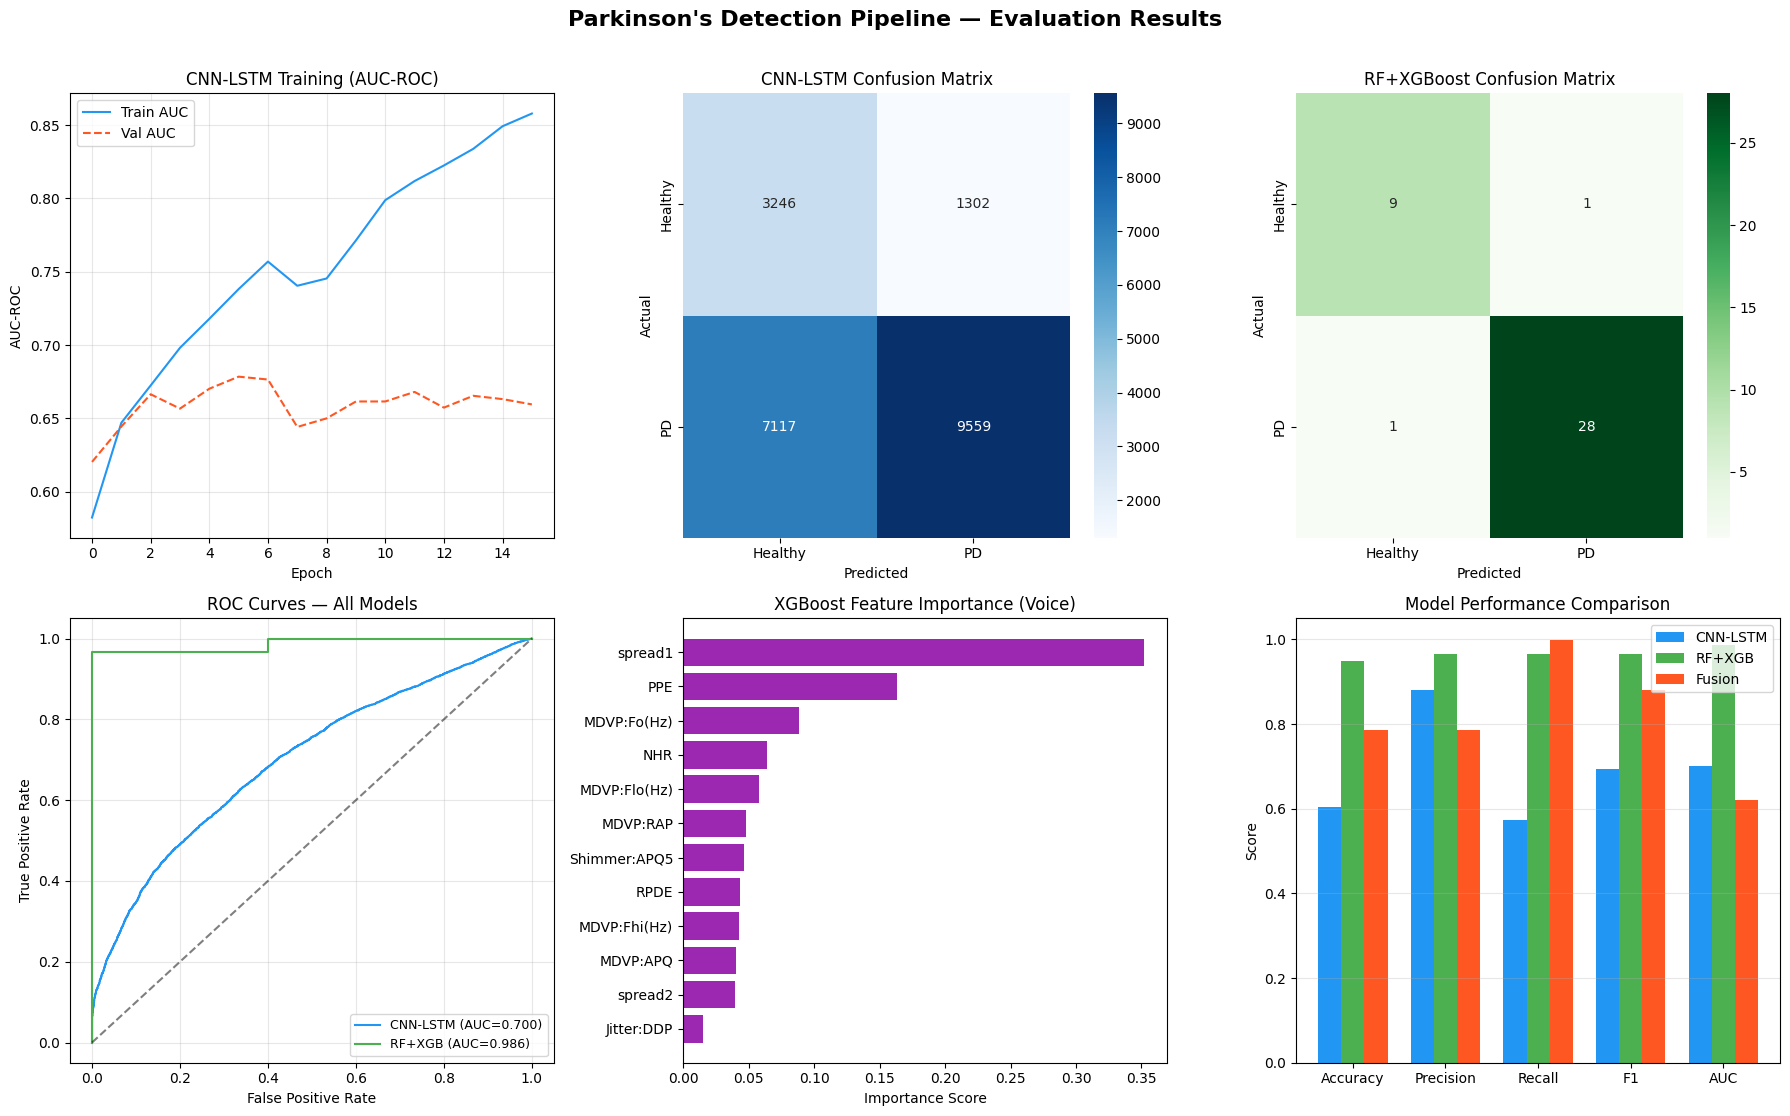

✅ Evaluation complete. Saved to /kaggle/working/evaluation_results.png


In [19]:
# ============================================================
# STEP 13: VISUALISATIONS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Parkinson's Detection Pipeline — Evaluation Results",
             fontsize=16, fontweight="bold", y=1.01)

# ── 1. CNN-LSTM Training History ─────────────────────────────
ax = axes[0, 0]
if 'cnn_lstm_history' in globals() and cnn_lstm_history is not None:
    hist = cnn_lstm_history.history
    ax.plot(hist["auc_roc"],     label="Train AUC", color="#2196F3")
    ax.plot(hist["val_auc_roc"], label="Val AUC",   color="#FF5722", linestyle="--")
    ax.set_title("CNN-LSTM Training (AUC-ROC)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC-ROC")
    ax.legend(); ax.grid(alpha=0.3)
else:
    ax.set_title("CNN-LSTM History - N/A")
    ax.text(0.5, 0.5, 'History not available', ha='center', va='center', transform=ax.transAxes)

# ── 2. CNN-LSTM Confusion Matrix ──────────────────────────────
ax = axes[0, 1]
if 'motion_pred_te' in globals() and 'y_te' in globals() and len(y_te) > 1:
    cm = confusion_matrix(y_te, motion_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("CNN-LSTM Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("CNN-LSTM Confusion Matrix - N/A")
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# ── 3. RF+XGBoost Confusion Matrix ───────────────────────────
ax = axes[0, 2]
if 'voice_pred_te' in globals() and 'y_voice_te' in globals() and len(y_voice_te) > 1:
    cm = confusion_matrix(y_voice_te, voice_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("RF+XGBoost Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("RF+XGBoost Confusion Matrix - N/A")
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# ── 4. ROC Curves ─────────────────────────────────────────────
ax = axes[1, 0]
roc_plots_data = []

if ('motion_proba_te' in globals() and 'y_te' in globals()
        and len(y_te) == len(motion_proba_te)
        and np.any(y_te == 0) and np.any(y_te == 1)):
    fpr, tpr, _ = roc_curve(y_te, motion_proba_te)
    auc = roc_auc_score(y_te, motion_proba_te)
    roc_plots_data.append((fpr, tpr, f"CNN-LSTM (AUC={auc:.3f})", "#2196F3"))

if ('voice_proba_te' in globals() and 'y_voice_te' in globals()
        and len(y_voice_te) == len(voice_proba_te)
        and np.any(y_voice_te == 0) and np.any(y_voice_te == 1)):
    fpr, tpr, _ = roc_curve(y_voice_te, voice_proba_te)
    auc = roc_auc_score(y_voice_te, voice_proba_te)
    roc_plots_data.append((fpr, tpr, f"RF+XGB (AUC={auc:.3f})", "#4CAF50"))

if ('fused_proba_te' in globals() and 'y_fused_te' in globals()
        and len(y_fused_te) == len(fused_proba_te)
        and np.any(y_fused_te == 0) and np.any(y_fused_te == 1)
        and globals().get('meta_model') is not None):
    fpr, tpr, _ = roc_curve(y_fused_te, fused_proba_te)
    auc = roc_auc_score(y_fused_te, fused_proba_te)
    roc_plots_data.append((fpr, tpr, f"Fusion (AUC={auc:.3f})", "#FF5722"))

if roc_plots_data:
    for fpr, tpr, label, color in roc_plots_data:
        ax.plot(fpr, tpr, label=label, color=color)
    ax.plot([0,1],[0,1], "k--", alpha=0.5)
    ax.set_title("ROC Curves — All Models")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
else:
    ax.set_title("ROC Curves - N/A")
    ax.text(0.5, 0.5, 'No ROC data available', ha='center', va='center', transform=ax.transAxes)

# ── 5. XGBoost Feature Importance ────────────────────────────
ax = axes[1, 1]
if 'xgb_model' in globals() and 'selected_voice_feats' in globals():
    imp_df = pd.DataFrame({
        "feature"   : selected_voice_feats,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance")
    ax.barh(imp_df["feature"], imp_df["importance"], color="#9C27B0")
    ax.set_title("XGBoost Feature Importance (Voice)")
    ax.set_xlabel("Importance Score")
else:
    ax.set_title("Feature Importance - N/A")
    ax.text(0.5, 0.5, 'Model not available', ha='center', va='center', transform=ax.transAxes)

# ── 6. Metrics Comparison ─────────────────────────────────────
ax = axes[1, 2]
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
keys    = ["accuracy", "precision", "recall", "f1", "auc"]

res_cnn   = globals().get('res_cnn',   {k: 0 for k in keys})
res_ens   = globals().get('res_ens',   {k: 0 for k in keys})
res_fused = globals().get('res_fused', {k: 0 for k in keys})

m_vals = [res_cnn[k]   for k in keys]
e_vals = [res_ens[k]   for k in keys]
f_vals = [res_fused[k] for k in keys]

if any(v > 0 for v in m_vals + e_vals + f_vals):
    x, w = np.arange(len(metrics)), 0.25
    ax.bar(x - w, m_vals, w, label="CNN-LSTM", color="#2196F3")
    ax.bar(x,     e_vals, w, label="RF+XGB",   color="#4CAF50")
    ax.bar(x + w, f_vals, w, label="Fusion",   color="#FF5722")
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.set_title("Model Performance Comparison")
    ax.set_ylabel("Score")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
else:
    ax.set_title("Performance Comparison - N/A")
    ax.text(0.5, 0.5, 'No results available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig("/kaggle/working/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Evaluation complete. Saved to /kaggle/working/evaluation_results.png")

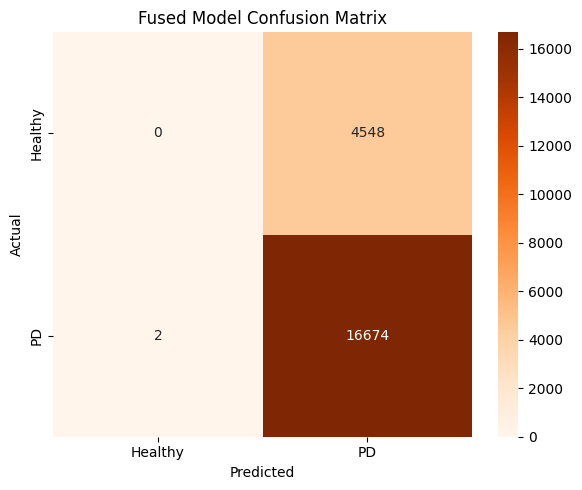

✅ Confusion matrices saved.


In [20]:
# ── 2. CNN-LSTM Confusion Matrix ──────────────────────────────
ax = axes[0, 1]
if 'motion_pred_te' in globals() and 'y_te' in globals() and len(y_te) > 1:
    cm = confusion_matrix(y_te, motion_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("CNN-LSTM Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("CNN-LSTM Confusion Matrix - N/A")
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# ── 3. RF+XGBoost Confusion Matrix ───────────────────────────
ax = axes[0, 2]
if 'voice_pred_te' in globals() and 'y_voice_te' in globals() and len(y_voice_te) > 1:
    cm = confusion_matrix(y_voice_te, voice_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("RF+XGBoost Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("RF+XGBoost Confusion Matrix - N/A")
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# ── Fused Model Confusion Matrix ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 5))
if 'fused_pred_te' in globals() and 'y_fused_te' in globals() and len(y_fused_te) > 1:
    cm = confusion_matrix(y_fused_te, fused_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax2,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax2.set_title("Fused Model Confusion Matrix")
    ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")
else:
    ax2.set_title("Fused Model Confusion Matrix - N/A")
    ax2.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrices saved.")

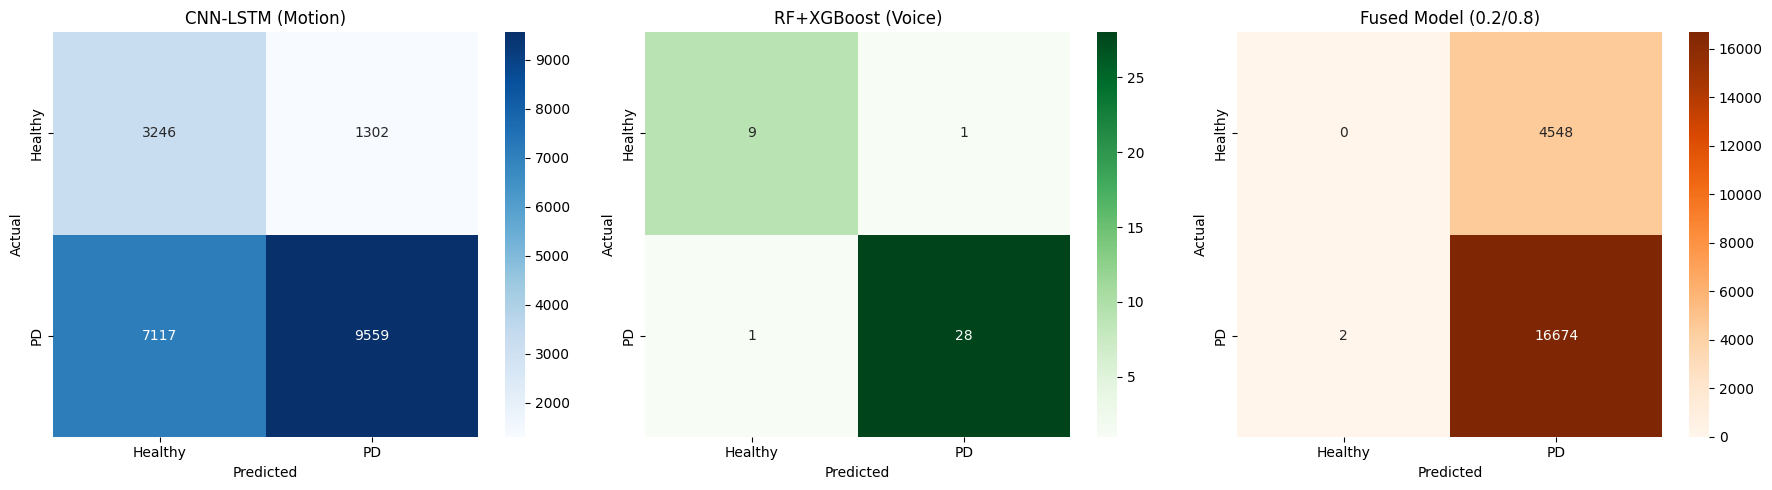

✅ Confusion matrices displayed and saved.


In [21]:
# ── All 3 Confusion Matrices ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#fig.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight="bold")

# CNN-LSTM
ax = axes[0]
if 'motion_pred_te' in globals() and 'y_te' in globals() and len(y_te) > 1:
    cm = confusion_matrix(y_te, motion_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("CNN-LSTM (Motion)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("CNN-LSTM - N/A")

# RF+XGBoost
ax = axes[1]
if 'voice_pred_te' in globals() and 'y_voice_te' in globals() and len(y_voice_te) > 1:
    cm = confusion_matrix(y_voice_te, voice_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("RF+XGBoost (Voice)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("RF+XGBoost - N/A")

# Fused Model
ax = axes[2]
if 'fused_pred_te' in globals() and 'y_fused_te' in globals() and len(y_fused_te) > 1:
    cm = confusion_matrix(y_fused_te, fused_pred_te)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax,
                xticklabels=["Healthy","PD"], yticklabels=["Healthy","PD"])
    ax.set_title("Fused Model (0.2/0.8)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
else:
    ax.set_title("Fused Model - N/A")

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrices displayed and saved.")

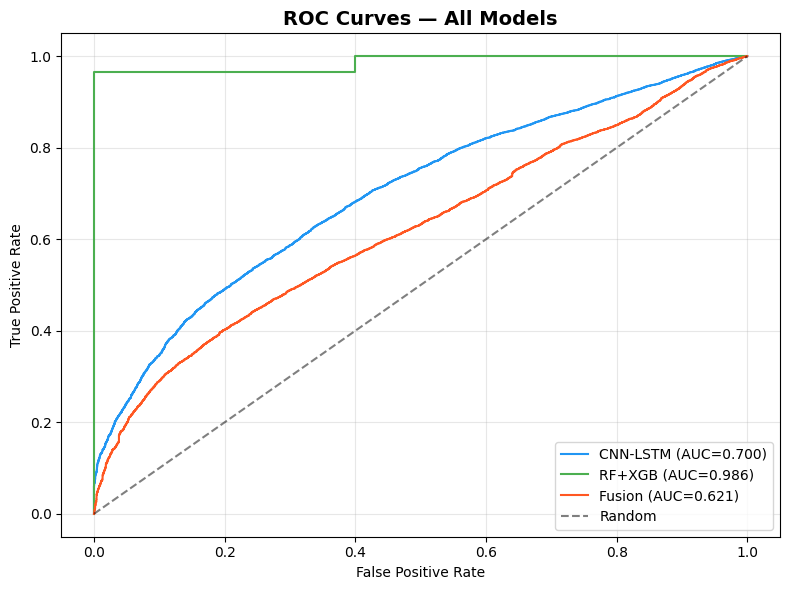

✅ ROC curves displayed and saved.


In [22]:
# ── ROC Curves — All Models ───────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# CNN-LSTM
if ('motion_proba_te' in globals() and 'y_te' in globals()
        and len(y_te) == len(motion_proba_te)
        and np.any(y_te == 0) and np.any(y_te == 1)):
    fpr, tpr, _ = roc_curve(y_te, motion_proba_te)
    auc = roc_auc_score(y_te, motion_proba_te)
    ax.plot(fpr, tpr, label=f"CNN-LSTM (AUC={auc:.3f})", color="#2196F3")

# RF+XGBoost
if ('voice_proba_te' in globals() and 'y_voice_te' in globals()
        and len(y_voice_te) == len(voice_proba_te)
        and np.any(y_voice_te == 0) and np.any(y_voice_te == 1)):
    fpr, tpr, _ = roc_curve(y_voice_te, voice_proba_te)
    auc = roc_auc_score(y_voice_te, voice_proba_te)
    ax.plot(fpr, tpr, label=f"RF+XGB (AUC={auc:.3f})", color="#4CAF50")

# Fused Model
if ('fused_proba_te' in globals() and 'y_fused_te' in globals()
        and len(y_fused_te) == len(fused_proba_te)
        and len(y_fused_te) > 1
        and np.any(y_fused_te == 0) and np.any(y_fused_te == 1)):
    fpr, tpr, _ = roc_curve(y_fused_te, fused_proba_te)
    auc = roc_auc_score(y_fused_te, fused_proba_te)
    ax.plot(fpr, tpr, label=f"Fusion (AUC={auc:.3f})", color="#FF5722")

ax.plot([0,1],[0,1], "k--", alpha=0.5, label="Random")
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves displayed and saved.")

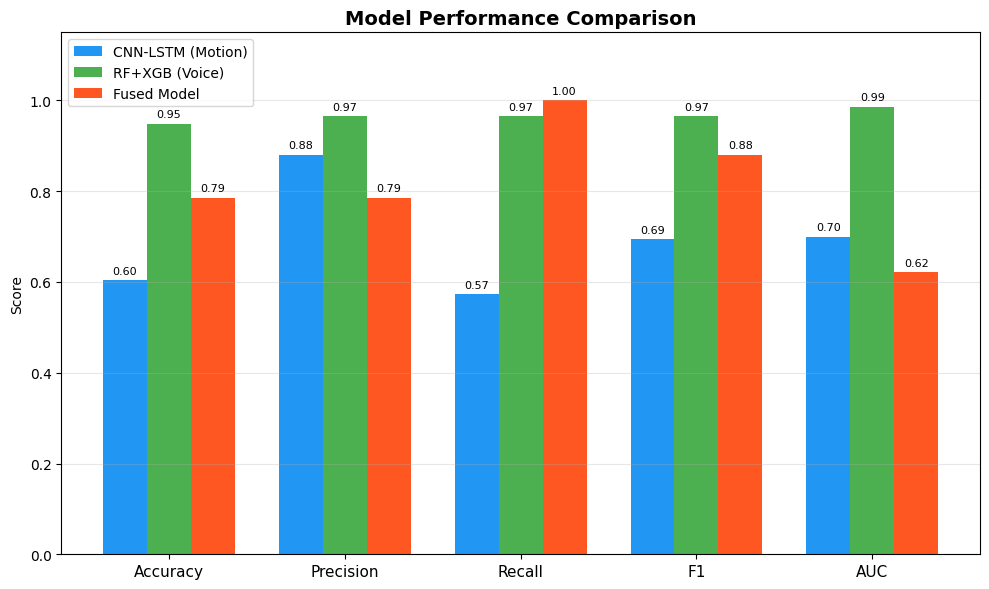

✅ Model comparison displayed and saved.


In [23]:
# ── Model Performance Comparison ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

keys    = ["accuracy", "precision", "recall", "f1", "auc"]
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

res_cnn   = globals().get('res_cnn',   {k: 0 for k in keys})
res_ens   = globals().get('res_ens',   {k: 0 for k in keys})
res_fused = globals().get('res_fused', {k: 0 for k in keys})

m_vals = [res_cnn[k]   for k in keys]
e_vals = [res_ens[k]   for k in keys]
f_vals = [res_fused[k] for k in keys]

fig, ax = plt.subplots(figsize=(10, 6))

x, w = np.arange(len(metrics)), 0.25
bars1 = ax.bar(x - w, m_vals, w, label="CNN-LSTM (Motion)", color="#2196F3")
bars2 = ax.bar(x,     e_vals, w, label="RF+XGB (Voice)",    color="#4CAF50")
bars3 = ax.bar(x + w, f_vals, w, label="Fused Model",       color="#FF5722")

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.2f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Model comparison displayed and saved.")

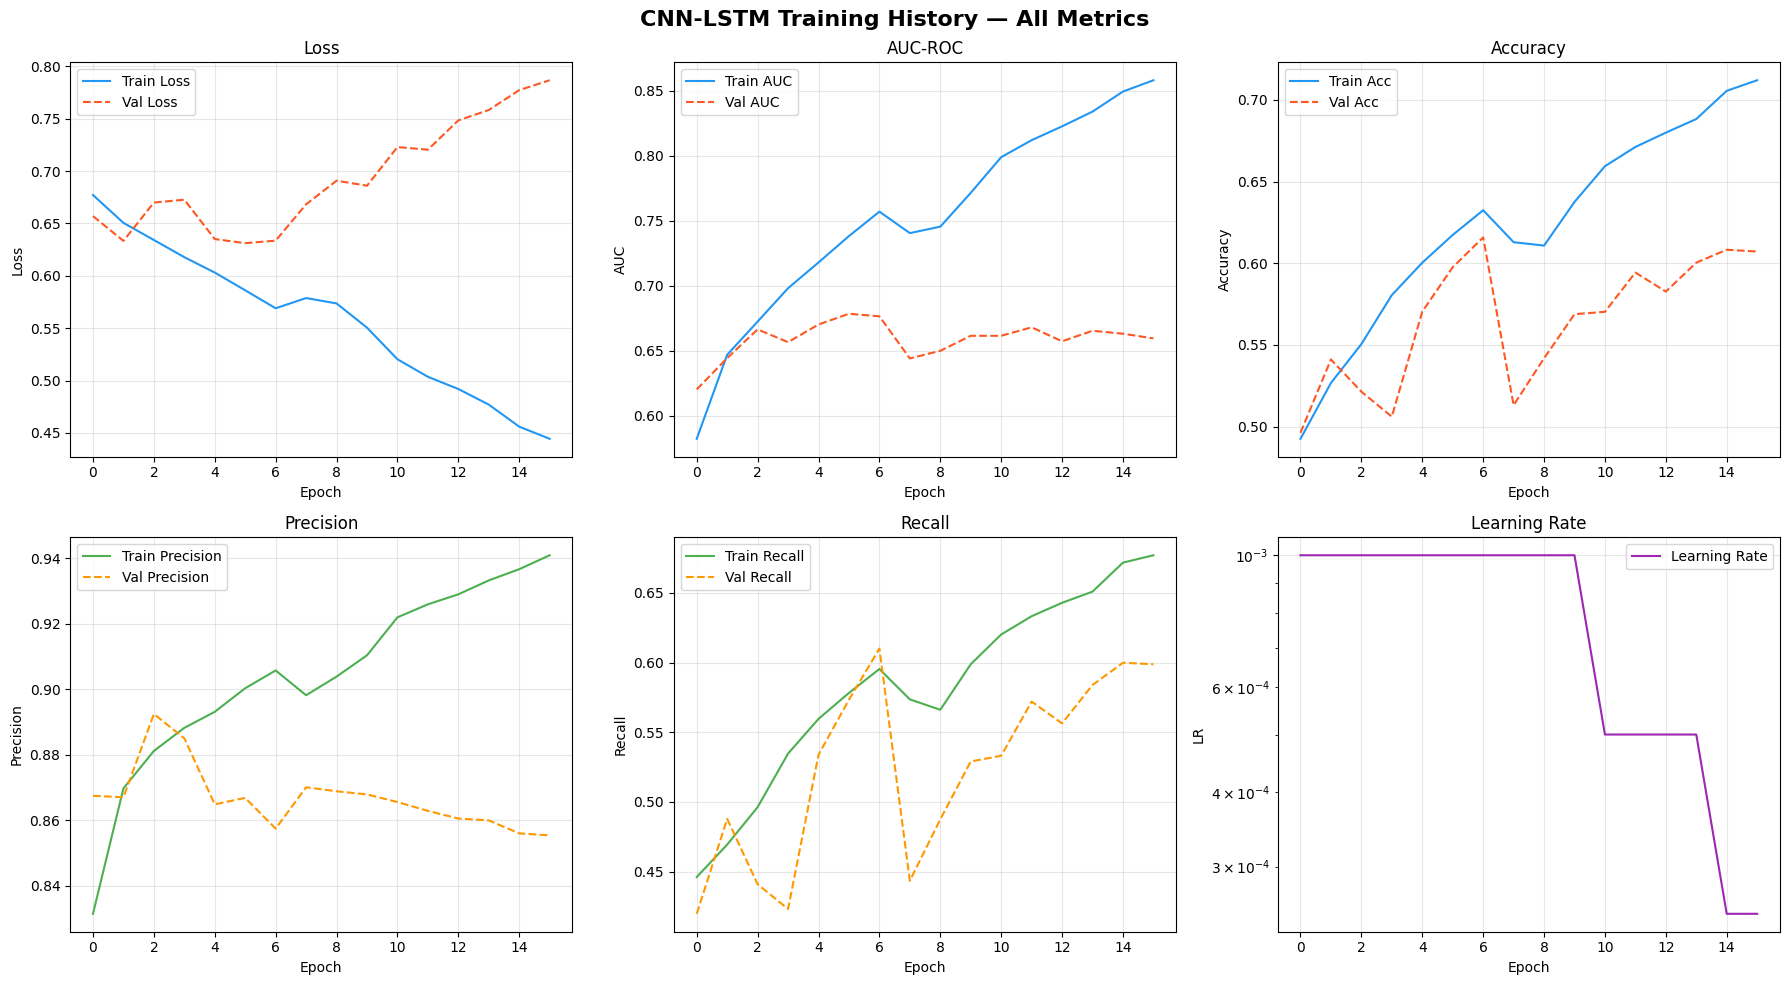

✅ Training history displayed and saved.


In [24]:
# ── CNN-LSTM Training History — All Metrics ───────────────────
import matplotlib.pyplot as plt
import json

with open('/kaggle/working/cnn_lstm_history.json', 'r') as f:
    hist = json.load(f)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("CNN-LSTM Training History — All Metrics",
             fontsize=16, fontweight="bold")

# 1. Loss
ax = axes[0, 0]
ax.plot(hist["loss"],     label="Train Loss", color="#2196F3")
ax.plot(hist["val_loss"], label="Val Loss",   color="#FF5722", linestyle="--")
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

# 2. AUC-ROC
ax = axes[0, 1]
ax.plot(hist["auc_roc"],     label="Train AUC", color="#2196F3")
ax.plot(hist["val_auc_roc"], label="Val AUC",   color="#FF5722", linestyle="--")
ax.set_title("AUC-ROC"); ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
ax.legend(); ax.grid(alpha=0.3)

# 3. Accuracy
ax = axes[0, 2]
ax.plot(hist["accuracy"],     label="Train Acc", color="#2196F3")
ax.plot(hist["val_accuracy"], label="Val Acc",   color="#FF5722", linestyle="--")
ax.set_title("Accuracy"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(alpha=0.3)

# 4. Precision
ax = axes[1, 0]
ax.plot(hist["precision"],     label="Train Precision", color="#4CAF50")
ax.plot(hist["val_precision"], label="Val Precision",   color="#FF9800", linestyle="--")
ax.set_title("Precision"); ax.set_xlabel("Epoch"); ax.set_ylabel("Precision")
ax.legend(); ax.grid(alpha=0.3)

# 5. Recall
ax = axes[1, 1]
ax.plot(hist["recall"],     label="Train Recall", color="#4CAF50")
ax.plot(hist["val_recall"], label="Val Recall",   color="#FF9800", linestyle="--")
ax.set_title("Recall"); ax.set_xlabel("Epoch"); ax.set_ylabel("Recall")
ax.legend(); ax.grid(alpha=0.3)

# 6. Learning Rate
ax = axes[1, 2]
ax.plot(hist["learning_rate"], label="Learning Rate", color="#9C27B0")
ax.set_title("Learning Rate"); ax.set_xlabel("Epoch"); ax.set_ylabel("LR")
ax.set_yscale("log")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Training history displayed and saved.")


         COMPLETE MODEL PERFORMANCE COMPARISON
     Metric  CNN-LSTM (Motion)  RF+XGB (Voice)  Fused Model (0.2/0.8)
   Accuracy             0.6033          0.9487                 0.7856
  Precision             0.8801          0.9655                 0.7857
     Recall             0.5732          0.9655                 0.9999
Specificity             0.7137          0.9000                 0.0000
   F1 Score             0.6943          0.9655                 0.8799
    AUC-ROC             0.6999          0.9862                 0.6210


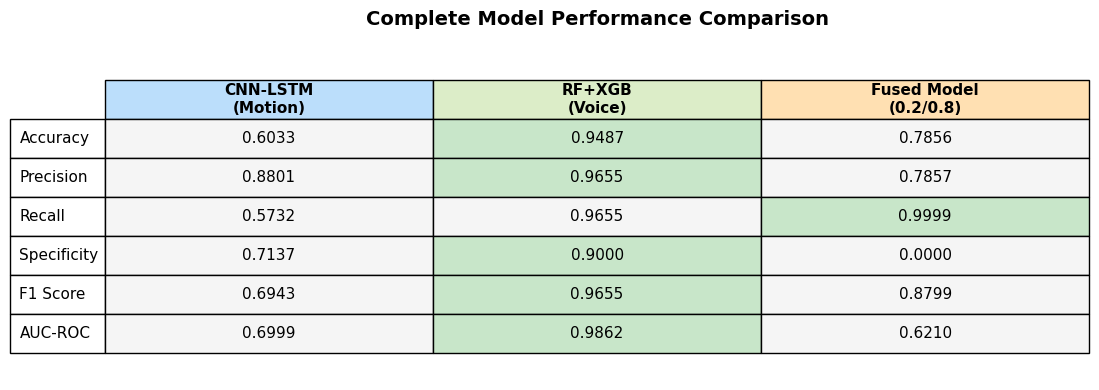

✅ Comparison table displayed and saved.


In [25]:
# ── Complete Model Comparison Table ──────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

keys    = ["accuracy", "precision", "recall", "specificity", "f1", "auc"]
labels  = ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score", "AUC-ROC"]

res_cnn   = globals().get('res_cnn',   {k: 0 for k in keys})
res_ens   = globals().get('res_ens',   {k: 0 for k in keys})
res_fused = globals().get('res_fused', {k: 0 for k in keys})

df = pd.DataFrame({
    "Metric"              : labels,
    "CNN-LSTM (Motion)"   : [res_cnn[k]   for k in keys],
    "RF+XGB (Voice)"      : [res_ens[k]   for k in keys],
    "Fused Model (0.2/0.8)": [res_fused[k] for k in keys],
})

# ── Print Table ───────────────────────────────────────────────
print("\n" + "="*65)
print("         COMPLETE MODEL PERFORMANCE COMPARISON")
print("="*65)
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*65)

# ── Plot Table ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = [labels,
              [f"{res_cnn[k]:.4f}"   for k in keys],
              [f"{res_ens[k]:.4f}"   for k in keys],
              [f"{res_fused[k]:.4f}" for k in keys]]

col_labels = ["CNN-LSTM\n(Motion)", "RF+XGB\n(Voice)", "Fused Model\n(0.2/0.8)"]
row_labels = ["Metric"] + col_labels

tbl = ax.table(
    cellText  = list(zip(*table_data[1:])),  # transpose
    rowLabels = labels,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 2.2)

# Color best value in each row green
model_vals = list(zip(
    [res_cnn[k]   for k in keys],
    [res_ens[k]   for k in keys],
    [res_fused[k] for k in keys]
))

for row_idx, vals in enumerate(model_vals):
    best_col = int(np.argmax(vals))
    for col_idx in range(3):
        cell = tbl[row_idx + 1, col_idx]
        if col_idx == best_col:
            cell.set_facecolor("#C8E6C9")  # green highlight
        else:
            cell.set_facecolor("#F5F5F5")

# Header colors
for col_idx, color in enumerate(["#BBDEFB", "#DCEDC8", "#FFE0B2"]):
    tbl[0, col_idx].set_facecolor(color)
    tbl[0, col_idx].set_text_props(fontweight='bold')

ax.set_title("Complete Model Performance Comparison",
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("/kaggle/working/model_comparison_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Comparison table displayed and saved.")